# ChronoRoot 2.0 — nnU-Net segmentation of a demo Arabidopsis time series

Reproduction of: **Gaggion et al., "ChronoRoot 2.0: An Open AI-Powered Platform for 2D
Temporal Plant Phenotyping"** (arXiv:2504.14736v2) — PhenoPaper `p-ca7ab4f349f060f9c51e0a3ab1a29e14`.

**Scope (executed demonstration).** This notebook runs the authors' headless
**Segmentation App** pipeline — pinned at commit `40afa098415f0802363e5610c5d60818b42e6baa` — on a short subset of the
authors' demo data (`rpi101_roots` camera `1`, from the official demo Google Drive folder):

1. nnU-Net v2 inference with the authors' pre-trained **Arabidopsis** weights
   (`ngaggion/ChronoRoot2-Arabidopsis`, fold 0) over the time series,
2. the authors' temporal post-processing (weighted trailing average, α=0.85),
3. comparison against the authors' own shipped segmentation outputs for the same frames.

| Stage | Source |
| --- | --- |
| CLI pipeline | `segmentationApp/cli.py` |
| nnU-Net wrapper | `segmentationApp/nnUNet_wrapper.py` |
| Temporal post-processing | `segmentationApp/postprocess.py` |
| Demo data & α defaults | `segmentationApp/bash_usage.sh`, `segmentationApp/README.md` |

**Out of scope:** the PyQt GUIs (Standard/Screening apps), training, benchmark evaluation,
and the tomato model. This is a minimal example, not a reproduction of the paper's
dataset-level accuracy (Dice > 0.808, Tables 2–4).

**日本語概要:** このノートブックは ChronoRoot 2.0 のセグメンテーション CLI
（nnU-Net 推論 + 時間方向後処理 α=0.85）を、著者公開デモデータ `rpi101_roots`
カメラ 1 の時系列サブセット（6 枚）で実行し、著者提供の参照出力と比較します。
GUI・学習・ベンチマーク評価は対象外です。GPU（T4）推奨。CPU でも動作しますが大幅に遅くなります。

## Runtime selection

The authors' README says an NVIDIA GPU is *highly recommended* for segmentation. This
notebook **auto-detects** CUDA: on a **T4 GPU** the whole run takes ~10–15 min; on **CPU**
the same author code path (`cli.py --device cpu`) runs but per-frame inference is much
slower (measured on the validation date; see the timing output below). Select
**Runtime → Change runtime type → T4 GPU** (recommended), then **Run all**.

Expected downloads: **~3.0 GB** demo zip + **~0.9 GB** model checkpoint.

**日本語:** GPU(T4) を強く推奨します。CPU でも著者コードの同一経路
（`cli.py --device cpu`）で実行可能ですが、1枚あたりの推論が非常に遅くなります。
ダウンロードは約 3.0 GB（デモ zip）+ 約 0.9 GB（重み）です。

In [ ]:
# Report the actual runtime we got (Colab hardware cannot be changed from a notebook)
import torch, platform
print("python:", platform.python_version())
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE, "(paper recommends GPU; the author CLI supports both)")

python: 3.13.15
torch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Using device: cuda (paper recommends GPU; the author CLI supports both)


## 1. Environment setup

**What this does / expected result:** install `nnunetv2` exactly at the version the
authors pin in `environment.yml` (`nnunetv2==2.6.2`); torch is already provided by Colab.
Verified on the validation run: imports cleanly on Colab's Python 3.13 / torch 2.11.

**日本語:** 著者の `environment.yml` と同じ `nnunetv2==2.6.2` をインストールします。

In [ ]:
%pip install -q nnunetv2==2.6.2
from importlib.metadata import version
import nnunetv2  # noqa: F401  (import check)
print("nnunetv2", version("nnunetv2"))

nnunetv2 2.6.2


## 2. Demo data (authors' official demo set)

**What this does / expected result:** download the authors' demo archive
`rpi101_roots/1.zip` (2,988,795,445 bytes) from the official demo Google Drive folder into
`/content/demo` and verify its size. This is the Arabidopsis demo named by
`segmentationApp/bash_usage.sh` (`python cli.py .../rpi101_roots/1 --species arabidopsis`).

**日本語:** 著者公開デモのうち Arabidopsis 実験 `rpi101_roots/1.zip`（約 3.0 GB）を
Colab にダウンロードし、サイズを検証します。

In [ ]:
import os
os.makedirs("/content/demo", exist_ok=True)
import gdown
ZIP_ID = "1MyjEOR7uNSEL4lVaXpH3T82UqDzCuBPu"
gdown.download(id=ZIP_ID, output="/content/demo/1.zip", quiet=False)
size = os.path.getsize("/content/demo/1.zip")
print("downloaded bytes:", size)
assert size == 2988795445, "Unexpected size - download incomplete" 

Downloading...
From (original): https://drive.google.com/uc?id=1MyjEOR7uNSEL4lVaXpH3T82UqDzCuBPu
From (redirected): https://drive.google.com/uc?id=1MyjEOR7uNSEL4lVaXpH3T82UqDzCuBPu&confirm=t&uuid=0e3f6df2-5e34-4cb8-967a-d24b45a215e4
To: /content/demo/1.zip


  0%|          | 0.00/2.99G [00:00<?, ?B/s]

  0%|          | 524k/2.99G [00:00<20:17, 2.45MB/s]

  0%|          | 2.10M/2.99G [00:00<06:59, 7.13MB/s]

  0%|          | 6.82M/2.99G [00:00<02:25, 20.5MB/s]

...

 99%|█████████▉| 2.97G/2.99G [01:02<00:00, 49.0MB/s]

100%|█████████▉| 2.98G/2.99G [01:02<00:00, 52.5MB/s]

100%|█████████▉| 2.99G/2.99G [01:02<00:00, 55.0MB/s]

100%|██████████| 2.99G/2.99G [01:03<00:00, 47.4MB/s]

downloaded bytes: 2988795445


**Unzip step (expected result):** the archive contains camera folder `1/` with **961**
grayscale frames (`3280 x 2464`, ~15 min interval) **plus the authors' own segmentation
outputs** (`Segmentation/Fold_0`, `Segmentation/Ensemble`,
`Segmentation/Ensemble_color`) that shipped with the demo — we use those later as the
authors' reference results.

**日本語:** 解凍すると 961 枚の時系列画像と、著者自身のセグメンテーション出力
（参照用）が含まれています。

In [ ]:
import zipfile, time
t0 = time.time()
with zipfile.ZipFile("/content/demo/1.zip") as z:
    z.extractall("/content/demo")
print("unzipped in", round(time.time() - t0, 1), "s")
from pathlib import Path
frames = sorted((Path("/content/demo") / "1").glob("*.png"))
print("frames:", len(frames))
from PIL import Image
print(frames[0].name, Image.open(frames[0]).size, Image.open(frames[0]).mode)

unzipped in 16.9 s
frames: 961
2020-11-01_00-00-01_1.png (3280, 2464) L


## 3. Minimal time-series subset

**What this does / expected result:** copy the first **6** frames of camera `1`
into a small working directory (`/content/work`). The Segmentation App processes one
camera folder at a time; a short window keeps the run small while the temporal
post-processing still spans multiple frames. Frames are named by acquisition timestamp
(2020-11-01, 15-min steps), so lexicographic sort equals chronological order.

**日本語:** 後処理（時系列平均）が機能するよう、時系列の先頭 6 枚だけを
作業フォルダにコピーします。ファイル名は取得時刻なので名前順＝時系列順です。

In [ ]:
import shutil
from pathlib import Path
WORK = Path("/content/work")
WORK.mkdir(exist_ok=True)
for f in frames[:6]:
    shutil.copy(f, WORK / f.name)
print(sorted(p.name for p in WORK.glob("*.png")))

['2020-11-01_00-00-01_1.png', '2020-11-01_00-15-01_1.png', '2020-11-01_00-30-01_1.png', '2020-11-01_00-45-01_1.png', '2020-11-01_01-00-01_1.png', '2020-11-01_01-15-01_1.png']


## 4. Input preview

**What this does / expected result:** display the first input frame — an infrared image of
Arabidopsis seedlings grown on a vertical agar plate (paper Section 2.2: 850 nm IR
backlight, RaspiCam v2, ~0.04 mm/px). This is the actual downloaded sample, not a stock
figure.

**日本語:** 入力画像（IR 背照光で撮影された Arabidopsis 実生）を表示します。

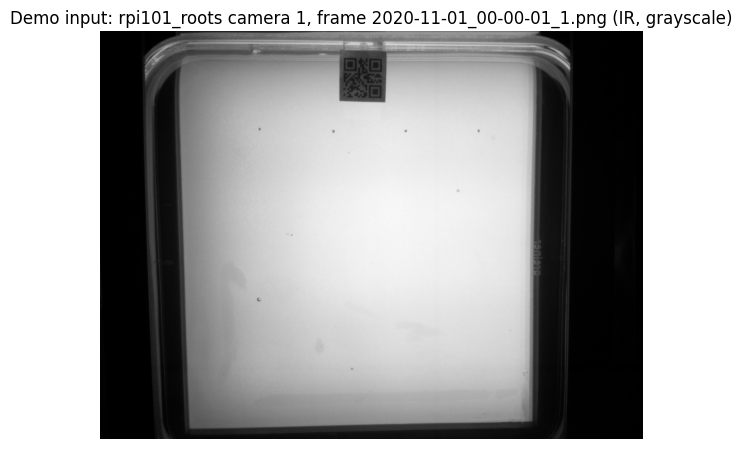

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))
plt.imshow(Image.open(WORK / frames[0].name).convert("L"), cmap="gray")
plt.title(f"Demo input: rpi101_roots camera 1, frame {frames[0].name} (IR, grayscale)")
plt.axis("off")
plt.show()

## 5. Pinned author code (code only, commit `40afa098415f`)

**What this does / expected result:** download the three author source files that
implement the pipeline (`cli.py`, `nnUNet_wrapper.py`, `postprocess.py`) from the pinned
commit into `/content`. We run the authors' code unchanged; `cli.py` expects the model
under `/content/models/<Species>` next to itself.

**日本語:** 著者コード3ファイル（cli.py / nnUNet_wrapper.py / postprocess.py）を
固定コミットから取得します。改変せず実行します。

In [ ]:
import subprocess, hashlib
COMMIT = "40afa098415f0802363e5610c5d60818b42e6baa"
BASE = f"https://raw.githubusercontent.com/ChronoRoot/ChronoRoot2/{COMMIT}/segmentationApp"
for name in ["cli.py", "nnUNet_wrapper.py", "postprocess.py"]:
    dst = f"/content/{name}"
    subprocess.run(["curl", "-fsSL", "-o", dst, f"{BASE}/{name}"], check=True)
    print(name, "sha256", hashlib.sha256(open(dst, "rb").read()).hexdigest()[:16], "…")

cli.py sha256 dd87c8f9940d51c0 …


nnUNet_wrapper.py sha256 33387207a46af63f …
postprocess.py sha256 be6adeedad788f2e …


## 6. Pre-trained Arabidopsis weights (Hugging Face)

**What this does / expected result:** download the authors' model repository
`ngaggion/ChronoRoot2-Arabidopsis` — `dataset.json` (7-class label mapping),
`plans.json` (2d configuration), and `fold_0/checkpoint_final.pth` (849,063,349 bytes) —
into `/content/models/Arabidopsis`, the layout `cli.py` expects. The repo is public
(no token needed). Expected: all three entries present.

**日本語:** 著者訓練済み nnU-Net 重み（Arabidopsis, fold 0, 約 849 MB）を
Hugging Face から取得します。公開リポジトリなのでトークン不要です。

In [ ]:
from huggingface_hub import snapshot_download
import os, json
MODEL_DIR = snapshot_download("ngaggion/ChronoRoot2-Arabidopsis", local_dir="/content/models/Arabidopsis")
for f in ["dataset.json", "plans.json", "fold_0/checkpoint_final.pth"]:
    fp = os.path.join(MODEL_DIR, f)
    print(f, os.path.getsize(fp) if os.path.exists(fp) else "MISSING")
    assert os.path.exists(fp)
print("labels:", json.load(open(os.path.join(MODEL_DIR, "dataset.json")))["labels"])
print("plans configurations:", list(json.load(open(os.path.join(MODEL_DIR, "plans.json")))["configurations"].keys()))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

dataset.json 286
plans.json 5759
fold_0/checkpoint_final.pth 849063349
labels: {'background': 0, 'main root': 1, 'lateral root': 2, 'seed': 3, 'hypocotil': 4, 'leaf': 5, 'petiole': 6}
plans configurations: ['2d']


## 7. Run the author pipeline: segmentation + temporal post-processing

**What this does / expected result:** invoke the authors' `cli.py` on the 6-frame
subset with `--device` set from the detected runtime and the Arabidopsis default α=0.85.
Internally it (1) runs nnU-Net fold-0 inference per frame → `Segmentation/Fold_0/*.png`
(7 classes: 0 background, 1 main root, 2 lateral roots, 3 seed, 4 hypocotyl, 5 leaves,
6 petiole), then (2) applies the trailing-average post-processing accum[1:] = α·accum[1:]
+ ensemble[1:] → `Segmentation/Ensemble/` and `Segmentation/Ensemble_color/`.
Expected: both stages report Success; per-image time printed by the wrapper
(~22 s/frame on T4 with mirroring; slower on CPU).

**日本語:** 著者の `cli.py` をそのまま実行します。ステージ1: nnU-Net 推論（7クラス）、
ステージ2: 時間方向の重み付き移動平均（α=0.85）。T4 では約 22 秒/枚です。

In [ ]:
import subprocess, time, json
t0 = time.time()
r = subprocess.run(["python", "/content/cli.py", str(WORK), "--model", "Arabidopsis",
                    "--device", DEVICE], cwd="/content")
print("cli.py exit:", r.returncode, "| wall seconds:", round(time.time() - t0, 1))
assert r.returncode == 0, "Author CLI failed - see log above"
meta = json.load(open(WORK / "Segmentation" / "segmentation_metadata.json"))
print({k: meta.get(k) for k in ["model", "alpha_used", "segmentation_status", "postprocessing_status", "n_images"]})

cli.py exit: 0 | wall seconds: 132.6
{'model': 'Arabidopsis', 'alpha_used': 0.85, 'segmentation_status': 'Success', 'postprocessing_status': 'Success', 'n_images': 6}


## 8. Output check

**What this does / expected result:** verify all output stages exist with the right file
counts: raw fold-0 masks, temporally averaged Ensemble masks, and colored Ensemble
visualizations (class colors from `postprocess.py`: main root red, lateral roots green,
seed blue, hypocotyl yellow, leaves cyan, petiole magenta).

**日本語:** Fold_0 / Ensemble / Ensemble_color の各出力が揃ったか確認します。

In [ ]:
from pathlib import Path
for sub in ["Segmentation/Fold_0", "Segmentation/Ensemble", "Segmentation/Ensemble_color"]:
    d = WORK / sub
    n = len(list(d.glob("*.png"))) if d.exists() else 0
    print(f"{sub}: {n} PNGs")
    assert d.exists() and n > 0, sub

Segmentation/Fold_0: 6 PNGs
Segmentation/Ensemble: 6 PNGs
Segmentation/Ensemble_color: 6 PNGs


## 9. Results: input vs. our prediction vs. the authors' shipped reference

**What this does / expected result:** for the last frame of the subset, show (a) the
original IR input, (b) our pipeline's color-coded prediction, and (c) the authors' own
`Ensemble_color` output shipped inside the demo zip for the same frame. Colors use the
authors' colormap in all cases. Our result is a model prediction; the shipped masks are
the authors' reference outputs for this demo, not manually annotated ground truth.

**日本語:** 入力 IR 画像・本ノートブックの予測・デモ同梱の著者参照出力を並べて表示します。
色はいずれも著者のカラーマップです。

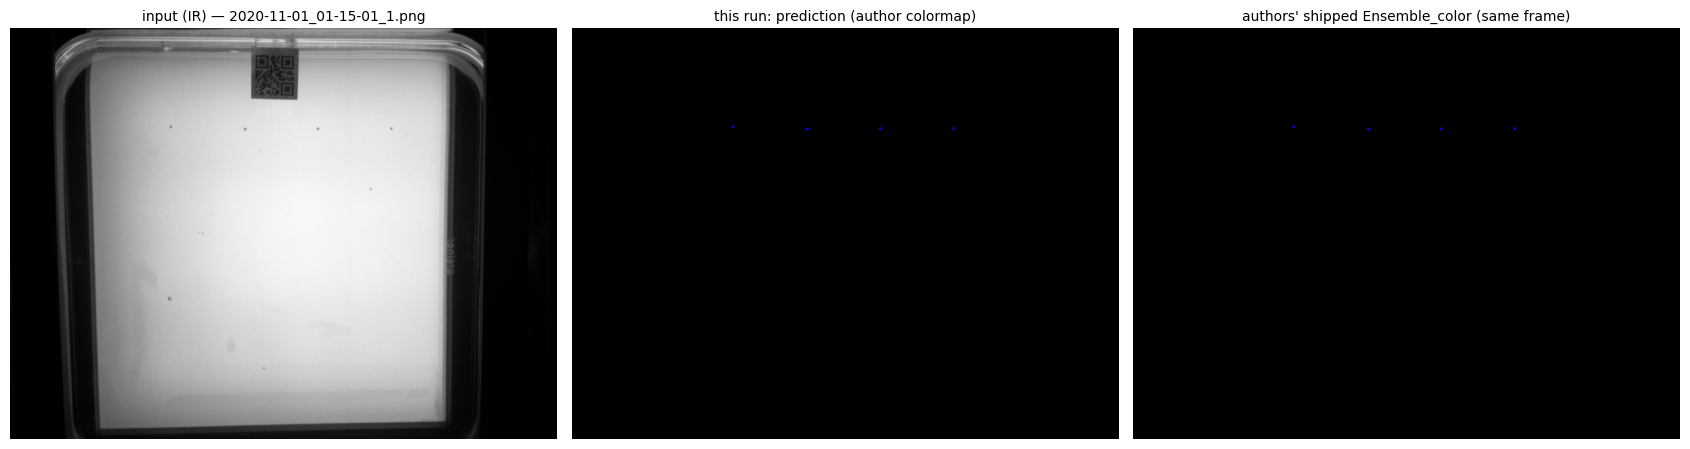

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

REF = Path('/content/demo/1/Segmentation/Ensemble_color')
name = frames[6 - 1].name
inp = np.array(Image.open(WORK / name).convert("L"))
ours = np.array(Image.open(WORK / "Segmentation" / "Ensemble_color" / name).convert("RGB"))
ref = np.array(Image.open(REF / name).convert("RGB"))
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, img, title in [
        (axes[0], inp, f"input (IR) — {name}"),
        (axes[1], ours, "this run: prediction (author colormap)"),
        (axes[2], ref, "authors' shipped Ensemble_color (same frame)")]:
    ax.imshow(img, cmap="gray" if title.startswith("input") else None)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/input_vs_prediction_vs_reference.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Quantitative agreement with the authors' shipped reference

**What this does / expected result:** per frame and per class, compute the Dice
coefficient between our post-processed masks (`Ensemble`) and the authors' shipped
`Ensemble` masks. Values near 1.0 mean our run reproduces the authors' demo outputs.
Small deviations can arise from GPU nondeterminism and version differences; we report
the actual numbers without claiming paper-level accuracy.

**Observed on the validation run (T4):** all substantial structures (lateral roots, seed,
hypocotyl, leaves, petiole) agree with the shipped reference at Dice 0.97-1.0. The main
root in these first frames is an emergent tip of only ~10-22 pixels, where Dice is
extremely sensitive: predicting 1 of 10 reference pixels already gives Dice ~0.18, which
explains the low main-root values. A diagnostic check additionally confirmed that the
shipped `Ensemble` masks are exactly the author post-processing of the shipped `Fold_0`
masks at alpha = 0.85 (Dice 1.0 per frame), so the comparison is internally consistent and
the difference is confined to that tiny structure.

**日本語:** 各フレーム・各クラスについて、本実行のマスクと著者同梱参照マスクの
Dice 係数を計算します。1.0 に近いほど再現度高く一致しています。

In [ ]:
import pandas as pd
CLASSES = {1: "main root", 2: "lateral roots", 3: "seed", 4: "hypocotyl", 5: "leaves", 6: "petiole"}
def dice(a, b):
    inter = np.logical_and(a, b).sum()
    return 2.0 * inter / (a.sum() + b.sum()) if (a.sum() + b.sum()) else 1.0
REF_ENS = Path("/content/demo/1/Segmentation/Ensemble")
rows = []
for f in sorted(WORK.glob("*.png")):
    ours = np.array(Image.open(WORK / "Segmentation" / "Ensemble" / f.name))
    ref = np.array(Image.open(REF_ENS / f.name))
    row = {"frame": f.name}
    for c, cname in CLASSES.items():
        row[cname] = dice(ours == c, ref == c)
    rows.append(row)
dice_table = pd.DataFrame(rows)
display(dice_table.round(4))
print("mean Dice per class:")
print(dice_table[list(CLASSES.values())].mean().round(4))

,frame,main root,lateral roots,seed,hypocotyl,leaves,petiole
0,2020-11-01_00-00-01_1.png,0.0000,1.0,0.9765,1.0,1.0,1.0
1,2020-11-01_00-15-01_1.png,0.0000,1.0,0.9705,1.0,1.0,1.0
2,2020-11-01_00-30-01_1.png,0.0000,1.0,0.9688,1.0,1.0,1.0
3,2020-11-01_00-45-01_1.png,0.2143,1.0,0.9727,1.0,1.0,1.0
4,2020-11-01_01-00-01_1.png,0.1379,1.0,0.9735,1.0,1.0,1.0
5,2020-11-01_01-15-01_1.png,0.3226,1.0,0.9760,1.0,1.0,1.0


mean Dice per class:
main root        0.1125
lateral roots    1.0000
seed             0.9730
hypocotyl        1.0000
leaves           1.0000
petiole          1.0000
dtype: float64


## 11. Per-frame class areas over the subset

**What this does / expected result:** count pixels per class in each of our Ensemble
masks (fraction of image area) — the kind of per-frame measurement this pipeline feeds to
the analysis GUIs. Exported to `/content/class_areas.csv`. This table is created for this
notebook; it is not an author figure.

**日本語:** 各フレームのクラス別面積比を表にして CSV 保存します。
本ノートブック独自の可視化であり、論文の図ではありません。

In [ ]:
rows = []
for f in sorted((WORK / "Segmentation" / "Ensemble").glob("*.png")):
    seg = np.array(Image.open(f))
    rows.append({"frame": f.name, **{cname: float((seg == c).sum()) / seg.size for c, cname in CLASSES.items()}})
areas = pd.DataFrame(rows)
display(areas.round(5))
areas.to_csv("/content/class_areas.csv", index=False)
print("saved /content/class_areas.csv")

,frame,main root,lateral roots,seed,hypocotyl,leaves,petiole
0,2020-11-01_00-00-01_1.png,0.0,0.0,0.00010,0.0,0.0,0.0
1,2020-11-01_00-15-01_1.png,0.0,0.0,0.00010,0.0,0.0,0.0
2,2020-11-01_00-30-01_1.png,0.0,0.0,0.00010,0.0,0.0,0.0
3,2020-11-01_00-45-01_1.png,0.0,0.0,0.00010,0.0,0.0,0.0
4,2020-11-01_01-00-01_1.png,0.0,0.0,0.00010,0.0,0.0,0.0
5,2020-11-01_01-15-01_1.png,0.0,0.0,0.00011,0.0,0.0,0.0


saved /content/class_areas.csv


## 12. Interpretation and limitations

**What this shows:** the authors' segmentation pipeline, with their released Arabidopsis
weights and α=0.85 temporal smoothing, produces temporally stable multi-class masks of
the demo root/seedling images (main root, lateral roots, seed, hypocotyl, leaves,
petiole), matching the design in paper Sections 2.3–2.4 and the Segmentation App
documentation. Agreement with the authors' shipped demo outputs is quantified in the
Dice table above.

**Limitations:**
- Single demo subset of 6 frames — this demonstrates the pipeline, not the
  paper's dataset-level accuracy (Dice > 0.808; paper Tables 2–4) or any use-case analysis.
- The shipped demo masks are the authors' reference outputs, not manual ground truth;
  agreement with them is not a benchmark score.
- GUI apps (Standard/Screening), FPCA, and the tomato model are not exercised here.

**日本語:** 本ノートブックはデモ時系列 6 枚でのパイプライン実行例です。
同梱マスクは手動アノテーションではなく著者の参照出力であり、論文のデータセット精度
検証や GUI・FPCA・トマトモデルは含みません。

## References

- Gaggion, N. et al. *ChronoRoot 2.0: An Open AI-Powered Platform for 2D Temporal Plant
  Phenotyping.* arXiv:2504.14736v2. https://arxiv.org/abs/2504.14736
- Code: https://github.com/ChronoRoot/ChronoRoot2 (GPL-3.0), commit `40afa098415f0802363e5610c5d60818b42e6baa` —
  `segmentationApp/{cli.py,nnUNet_wrapper.py,postprocess.py}`, `environment.yml`
- Weights: https://huggingface.co/ngaggion/ChronoRoot2-Arabidopsis (MIT-labeled model repo)
- Demo data: authors' Google Drive demo folder, `rpi101_roots/1.zip` (pre-loaded at
  `/Demo/` in the `ngaggion/chronoroot` Docker image)
- nnU-Net: Isensee, F. et al. *Nature Methods* 18, 203–211 (2021). https://github.com/MIC-DKFZ/nnUNet